In [1]:
pip install tensorflow_datasets

Note: you may need to restart the kernel to use updated packages.


In [2]:
import tensorflow_datasets as tfds
import numpy as np
import tensorflow as tf


In [6]:
imdb,info=tfds.load('imdb_reviews', with_info=True, as_supervised=True) # include metadata (text, label) dictionary

C:\Users\UserH\Desktop\NLP\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dl Completed...: 0 url [00:00, ? url/s]
Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]
Generating train examples...: 0 examples [00:00, ? examples/s]
Generating train examples...: 1 examples [00:01,  1.24s/ examples]
Generating train examples...: 10055 examples [00:02, 5388.29 examples/s]
Generating train examples...: 20174 examples [00:03, 7438.52 examples/s]
                                                                        
Shuffling C:\Users\UserH\tensorflow_datasets\imdb_reviews\plain_text\incomplete.4YHSIT_1.0.0\imdb_reviews-train.tfrecord-[0-9][0-9][0-9][0-9][0-9]-of-[0-9][0-9][0-9][0-9][0-9]...:   0%|          | 0/25000 [00:00<?, ? examples/s]
Generating splits...:  33%|███▎      | 1/3 [00:06<00:12,  6.08s/ splits]                                                                                                                                                            
Generating test examples...: 0 examples [00:00, ? examples/s]
Generating test examples..

Dataset imdb_reviews downloaded and prepared to C:\Users\UserH\tensorflow_datasets\imdb_reviews\plain_text\1.0.0. Subsequent calls will reuse this data.


In [7]:
info

tfds.core.DatasetInfo(
    name='imdb_reviews',
    full_name='imdb_reviews/plain_text/1.0.0',
    description="""
    Large Movie Review Dataset. This is a dataset for binary sentiment
    classification containing substantially more data than previous benchmark
    datasets. We provide a set of 25,000 highly polar movie reviews for training,
    and 25,000 for testing. There is additional unlabeled data for use as well.
    """,
    config_description="""
    Plain text
    """,
    homepage='http://ai.stanford.edu/~amaas/data/sentiment/',
    data_dir='C:\\Users\\UserH\\tensorflow_datasets\\imdb_reviews\\plain_text\\1.0.0',
    file_format=tfrecord,
    download_size=80.23 MiB,
    dataset_size=129.83 MiB,
    features=FeaturesDict({
        'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
        'text': Text(shape=(), dtype=string),
    }),
    supervised_keys=('text', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'test': <

In [8]:
#imdb
info.splits

{Split('train'): <SplitInfo num_examples=25000, num_shards=1>,
 Split('test'): <SplitInfo num_examples=25000, num_shards=1>,
 Split('unsupervised'): <SplitInfo num_examples=50000, num_shards=1>}

In [9]:
train_data,test_data=imdb['train'],imdb['test']

In [10]:
training_sentences =[]
training_labels =[]

testing_sentences =[]
testing_labels =[]

for s, l in train_data:
    training_sentences.append(str(s.numpy()))
    training_labels.append(l.numpy())
for s, l in test_data:
    testing_sentences.append(str(s.numpy()))
    testing_labels.append(l.numpy())
    

In [11]:
training_labels

[np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(1),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(0),
 np.int64(1),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(0),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(0),
 np.int64(0),
 np.int64(1),
 np.int64(0),
 np.int64(0),
 np.in

In [12]:
training_sentences[0]

'b"This was an absolutely terrible movie. Don\'t be lured in by Christopher Walken or Michael Ironside. Both are great actors, but this must simply be their worst role in history. Even their great acting could not redeem this movie\'s ridiculous storyline. This movie is an early nineties US propaganda piece. The most pathetic scenes were those when the Columbian rebels were making their cases for revolutions. Maria Conchita Alonso appeared phony, and her pseudo-love affair with Walken was nothing but a pathetic emotional plug in a movie that was devoid of any real meaning. I am disappointed that there are movies like this, ruining actor\'s like Christopher Walken\'s good name. I could barely sit through it."'

In [13]:
# 0 is neg,1 is pos

training_labels[0]

np.int64(0)

In [14]:
testing_sentences[0]

'b"There are films that make careers. For George Romero, it was NIGHT OF THE LIVING DEAD; for Kevin Smith, CLERKS; for Robert Rodriguez, EL MARIACHI. Add to that list Onur Tukel\'s absolutely amazing DING-A-LING-LESS. Flawless film-making, and as assured and as professional as any of the aforementioned movies. I haven\'t laughed this hard since I saw THE FULL MONTY. (And, even then, I don\'t think I laughed quite this hard... So to speak.) Tukel\'s talent is considerable: DING-A-LING-LESS is so chock full of double entendres that one would have to sit down with a copy of this script and do a line-by-line examination of it to fully appreciate the, uh, breadth and width of it. Every shot is beautifully composed (a clear sign of a sure-handed director), and the performances all around are solid (there\'s none of the over-the-top scenery chewing one might\'ve expected from a film like this). DING-A-LING-LESS is a film whose time has come."'

In [15]:
testing_labels[0]

np.int64(1)

In [16]:
len(training_sentences),len(testing_sentences)

(25000, 25000)

In [17]:
len(training_labels),len(testing_labels)

(25000, 25000)

In [18]:
training_labels = np.array(training_labels)
testing_labels = np.array(testing_labels)

## Preprocessing


In [19]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [20]:
tokenizer = Tokenizer(num_words=10000) # vocabulary size (most frequencing words)
type(training_sentences[0])
str

str

In [21]:
tokenizer.fit_on_texts(training_sentences)
word_index=tokenizer.word_index

In [22]:
sequences = tokenizer.texts_to_sequences(training_sentences)
padded = pad_sequences(sequences,maxlen=500, truncating='post', padding='post')


testing_sequences = tokenizer.texts_to_sequences(testing_sentences)
testing_padded = pad_sequences(testing_sequences,maxlen=500, truncating='post', padding='post')


In [23]:
padded.shape

(25000, 500)

In [24]:
padded[0]

array([  58,   11,   13,   34,  438,  399,   17,  173,   28,    8,   32,
       1377, 3400,   41,  495,  196,   24,   87,  155,   18,   11,  210,
        339,   28,   69,  247,  212,    8,  485,   61,   69,   87,  115,
         98,   23, 5739,   11, 3316,  656,  776,   11,   17,    6,   34,
        405, 8227,  177, 2476,  425,    1,   91, 1252,  139,   71,  148,
         54,    1, 7524,   71,  228,   69, 2961,   15, 2879, 1505, 4997,
          2,   39, 3946,  118, 1607,   16, 3400,   13,  162,   18,    3,
       1252,  926, 7985,    8,    3,   17,   12,   13, 4199,    4,  101,
        147, 1236,   10,  239,  691,   12,   43,   24,  100,   38,   11,
       7231,   38, 1377,   51,  408,   10,   98, 1213,  873,  144,    9,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,   

## Build The Model with LSTM,GRU ,Bidirectional

In [25]:
from keras.models import Sequential
from keras.layers import Dense,Embedding,SimpleRNN,Bidirectional,LSTM,GRU

## Simple RNN

In [26]:
#50 is embedding dimension
model_rnn = Sequential([
    Embedding(10000, 50, input_length = 500),
    SimpleRNN(32),
    Dense(10,activation='relu'),
    Dense(1,activation='sigmoid')

])

C:\Users\UserH\Desktop\NLP\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [27]:
model_rnn.compile(loss = 'binary_crossentropy', optimizer='adam',metrics=['accuracy'])

In [28]:
history = model_rnn.fit(padded, training_labels, epochs = 10, validation_data= (testing_padded,testing_labels))

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 36s 44ms/step - accuracy: 0.5013 - loss: 0.6937 - val_accuracy: 0.5034 - val_loss: 0.6939
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 34s 44ms/step - accuracy: 0.5256 - loss: 0.6809 - val_accuracy: 0.5029 - val_loss: 0.6954
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 34s 44ms/step - accuracy: 0.5198 - loss: 0.6901 - val_accuracy: 0.4931 - val_loss: 0.6976
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 34s 44ms/step - accuracy: 0.5202 - loss: 0.6885 - val_accuracy: 0.5068 - val_loss: 0.6976
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 34s 44ms/step - accuracy: 0.5222 - loss: 0.6866 - val_accuracy: 0.5005 - val_loss: 0.6949
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 34s 44ms/step - accuracy: 0.5170 - loss: 0.6818 - val_accuracy: 0.5031 - val_loss: 0.6979
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 34s 44ms/step - accuracy: 0.5226 - loss: 0.6792 - val_accuracy: 0.5053 - val_loss: 0.7089
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 34s 44ms/step - accuracy: 0.5250 - loss: 0.6773 - 

In [30]:
import matplotlib.pyplot as plt

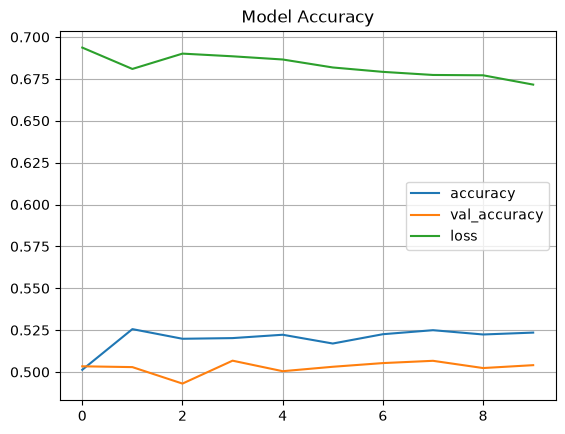

In [31]:
plt.plot(history.history['accuracy'], label ='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.plot(history.history['loss'], label = 'loss')
plt.title('Model Accuracy')
plt.grid()
plt.legend()

## LSTM

In [32]:
model_lstm = Sequential([
    Embedding(10000, 50, input_length = 500),
    LSTM(32),
    Dense(10,activation='relu'),
    Dense(1,activation='sigmoid')

])

C:\Users\UserH\Desktop\NLP\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [33]:
model_lstm.compile(loss = 'binary_crossentropy', optimizer='adam',
                metrics=['accuracy'])

In [34]:
history_lstm = model_lstm.fit(padded, training_labels, epochs = 10, validation_data= (testing_padded,testing_labels))

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 60s 75ms/step - accuracy: 0.5046 - loss: 0.6931 - val_accuracy: 0.5049 - val_loss: 0.6923
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 58s 74ms/step - accuracy: 0.5164 - loss: 0.6872 - val_accuracy: 0.5104 - val_loss: 0.6913
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 58s 75ms/step - accuracy: 0.5326 - loss: 0.6643 - val_accuracy: 0.5122 - val_loss: 0.7036
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 58s 74ms/step - accuracy: 0.5377 - loss: 0.6487 - val_accuracy: 0.5110 - val_loss: 0.7244
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 58s 75ms/step - accuracy: 0.5395 - loss: 0.6440 - val_accuracy: 0.5114 - val_loss: 0.7291
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 58s 75ms/step - accuracy: 0.5402 - loss: 0.6411 - val_accuracy: 0.5093 - val_loss: 0.7394
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 58s 75ms/step - accuracy: 0.5476 - loss: 0.6413 - val_accuracy: 0.6467 - val_loss: 0.7051
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 58s 74ms/step - accuracy: 0.7618 - loss: 0.5407 - 

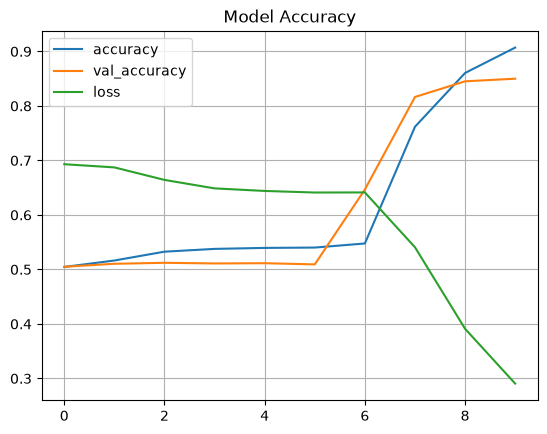

In [35]:
plt.plot(history_lstm.history['accuracy'], label ='accuracy')
plt.plot(history_lstm.history['val_accuracy'], label = 'val_accuracy')
plt.plot(history_lstm.history['loss'], label = 'loss')
plt.title('Model Accuracy')
plt.grid()
plt.legend()

## GRU

In [36]:
model_gru = Sequential([
    Embedding(10000, 50, input_length = 500),
    GRU(32),
    Dense(10,activation='relu'),
    Dense(1,activation='sigmoid')

])

In [37]:
model_gru.compile(loss = 'binary_crossentropy', optimizer='adam',
                metrics=['accuracy'])

In [38]:
history_gru = model_gru.fit(padded, training_labels, epochs = 10, validation_data= (testing_padded,testing_labels))

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 67s 84ms/step - accuracy: 0.5056 - loss: 0.6932 - val_accuracy: 0.5047 - val_loss: 0.6930
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 65s 83ms/step - accuracy: 0.5177 - loss: 0.6852 - val_accuracy: 0.5105 - val_loss: 0.6938
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 65s 83ms/step - accuracy: 0.5307 - loss: 0.6615 - val_accuracy: 0.5073 - val_loss: 0.7077
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 65s 84ms/step - accuracy: 0.5381 - loss: 0.6466 - val_accuracy: 0.5110 - val_loss: 0.7417
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 65s 83ms/step - accuracy: 0.5360 - loss: 0.6421 - val_accuracy: 0.5115 - val_loss: 0.7502
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 65s 83ms/step - accuracy: 0.7230 - loss: 0.5370 - val_accuracy: 0.8506 - val_loss: 0.3763
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 65s 83ms/step - accuracy: 0.9095 - loss: 0.2341 - val_accuracy: 0.8829 - val_loss: 0.2917
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 65s 83ms/step - accuracy: 0.9574 - loss: 0.1288 - 

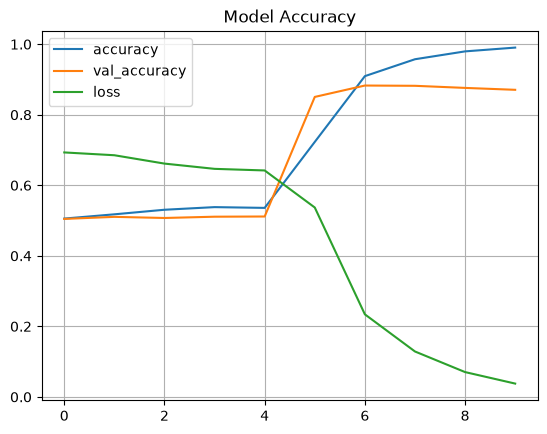

In [39]:
plt.plot(history_gru.history['accuracy'], label ='accuracy')
plt.plot(history_gru.history['val_accuracy'], label = 'val_accuracy')
plt.plot(history_gru.history['loss'], label = 'loss')
plt.title('Model Accuracy')
plt.grid()
plt.legend()

## Three Models Comparison

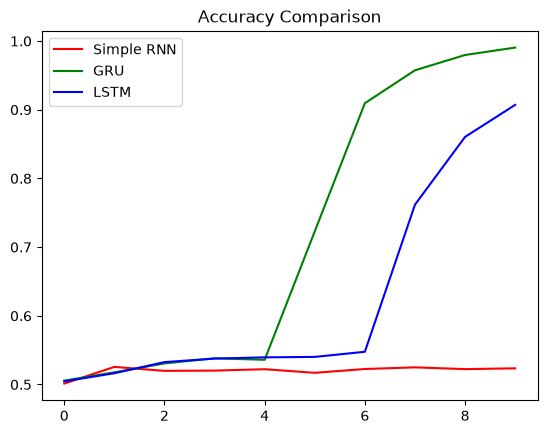

In [40]:
plt.title('Accuracy Comparison')

plt.plot(history.history['accuracy'], label ='Simple RNN', color = 'r')

plt.plot(history_gru.history['accuracy'], label ='GRU', color = 'g')

plt.plot(history_lstm.history['accuracy'], label ='LSTM', color = 'b')

plt.legend()


In [41]:
new1 = 'This was worst moview. Please do not watch it. WAste of money and time.'
new2 = 'A must watch movie. I lived to watch it. It was just amazing.'